# Crawling & Analisis Data Polutan Udara di Kabupaten Pamekasan

<!-- # Pemantauan Kualitas Udara Kabupaten Pamekasan Berbasis Data Satelit Sentinel-5P -->

Nama : Rian Renaldy

NIM : 240411100053

Mata Kuliah : Pengantar Sains Data (PSD)

## Gambaran Wilayah Analisa

Kabupaten Pamekasan terletak di bagian tengah Pulau Madura, Provinsi Jawa Timur. Berbeda dari kawasan industri besar, karakter utama wilayah ini didominasi oleh **sektor agraris** (padi, jagung, tembakau), **peternakan sapi** (Pamekasan dikenal sebagai salah satu sentra karapan sapi di Madura), **produksi garam rakyat** di kawasan pesisir, serta aktivitas **perikanan tangkap** dengan kapal-kapal nelayan bermesin diesel. Selain itu, jalur distribusi barang lintas Madura (menghubungkan Bangkalan &ndash; Sampang &ndash; Pamekasan &ndash; Sumenep) turut menyumbang emisi kendaraan bermotor. Kombinasi aktivitas pertanian, peternakan, perikanan, dan transportasi darat ini berpotensi memengaruhi konsentrasi berbagai gas pencemar udara, meliputi Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Sulfur Dioksida (SO2), Ozon troposferik (O3), Formaldehida (HCHO), dan Metana (CH4). Pemantauan keenam gas tersebut dari waktu ke waktu diperlukan untuk memahami karakteristik kualitas udara di Pamekasan.

## 1. Business Understanding

### 1.1 Latar Belakang

Pemantauan kualitas udara menjadi hal penting untuk dilakukan, mengingat polutan di atmosfer dapat bersumber dari berbagai aktivitas manusia (transportasi, industri, maupun pertanian) ataupun dari proses alami. Komposisi sumber polutan ini dapat berbeda-beda antarwilayah, bergantung pada karakteristik ekonomi dan geografis masing-masing daerah. Kabupaten Pamekasan sendiri memiliki karakteristik khas, seperti aktivitas pertanian dan peternakan sapi, produksi garam, perikanan, serta jalur lintas transportasi di Pulau Madura, yang berpotensi menjadi sumber emisi tersendiri bagi tiap jenis polutan. Analisis pada tugas ini difokuskan pada enam jenis polutan udara di wilayah Kabupaten Pamekasan dengan memanfaatkan data satelit Sentinel-5P selama periode pengamatan kurang lebih satu tahun.

### 1.2 Tujuan Analisis

Menelusuri sumber-sumber utama polutan udara serta memetakan kondisi kualitas udara di wilayah Kabupaten Pamekasan, melalui pengambilan data satelit untuk enam parameter (CO, NO2, SO2, O3, HCHO, CH4), dilanjutkan dengan eksplorasi data (*data understanding*), dan divisualisasikan dalam bentuk *time series* untuk rentang waktu minimal satu tahun hingga 31 Agustus 2026.

### 1.3 Manfaat Analisis

1. Memetakan pola naik-turunnya konsentrasi tiap gas pencemar di Pamekasan sepanjang periode pengamatan.
2. Menduga kontribusi aktivitas lokal (pertanian, peternakan, produksi garam, perikanan, transportasi) terhadap tiap jenis polutan.
3. Menyediakan gambaran awal kualitas udara yang bisa menjadi rujukan warga maupun pemangku kebijakan setempat.
4. Menjadi pijakan data (baseline) untuk tahap pembersihan data dan pemodelan pada pertemuan berikutnya.
5. Melatih keterampilan pengambilan data satelit (remote sensing crawling) serta eksplorasi data deret waktu lingkungan.

### 1.4 Dugaan Sumber Tiap Polutan

| Polutan | Apa Itu? | Dugaan Sumber di Pamekasan |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna & tak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna | Knalpot kendaraan bermotor, mesin kapal nelayan diesel, pembakaran jerami/lahan pertanian sisa panen |
| **NO2** (Nitrogen Dioksida) | Gas oksida nitrogen hasil pembakaran suhu tinggi | Emisi kendaraan bermotor di jalur lintas Madura, genset/mesin diesel kapal nelayan dan penggilingan |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung unsur belerang | Mesin kapal nelayan berbahan bakar solar, proses evaporasi/pengolahan air laut pada tambak garam, pembakaran bahan bakar fosil skala kecil |
| **O3** (Ozon Troposferik) | Bukan diemisikan langsung; polutan sekunder hasil reaksi fotokimia NOx dengan senyawa organik volatil di bawah sinar matahari | Terbentuk secara tidak langsung dari interaksi emisi kendaraan dan sinar matahari, umum meningkat pada siang hari cerah |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran biomassa/limbah pertanian, oksidasi metana dari peternakan, serta emisi kendaraan bermotor |
| **CH4** (Metana) | Gas rumah kaca, terkait erat dengan siklus biologis | Fermentasi enterik ternak sapi, lahan sawah tergenang air, dan dekomposisi limbah organik/TPA |

### 1.5 Deskripsi Umum Data

Data yang dipakai bersumber dari misi satelit **Sentinel-5P (instrumen TROPOMI)** yang dikelola oleh Copernicus/ESA, diakses melalui layanan **openEO** pada **Copernicus Data Space Ecosystem (CDSE)**. Data berupa nilai kerapatan kolom (*column density*) harian tiap gas pada resolusi grid tertentu, yang kemudian dirata-ratakan dalam batas wilayah analisa untuk membentuk satu nilai per hari per polutan.

## 2. Penetapan Area Analisa (AOI) Melalui GeoJSON.io

Batas wilayah pengambilan data digambar secara manual pada [geojson.io](https://geojson.io) dalam bentuk poligon yang mencakup Kabupaten Pamekasan, lalu diekspor sebagai berkas `.geojson`. Dari poligon tersebut dihitung *bounding box* (kotak pembatas terluar) yang menjadi parameter `spatial_extent` saat memanggil data pada openEO.

In [1]:
import json

# Poligon area analisa (AOI) Kabupaten Pamekasan, hasil gambar manual pada geojson.io
aoi_pamekasan = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [113.5876958, -6.9670461],
                        [113.603825, -7.0270799],
                        [113.6179379, -7.1151155],
                        [113.5554375, -7.1931807],
                        [113.5272115, -7.2511372],
                        [113.4827865, -7.2244607],
                        [113.4264044, -7.2191357],
                        [113.4042268, -7.0911074],
                        [113.4324528, -6.9830559],
                        [113.4243882, -6.8889907],
                        [113.5872728371105, -6.898785199566333],
                        [113.5876958, -6.9670461]
                    ]
                ]
            }
        }
    ]
}

with open("aoi_pamekasan.geojson", "w") as f:
    json.dump(aoi_pamekasan, f, indent=2)

print("Berkas aoi_pamekasan.geojson tersimpan.")


Berkas aoi_pamekasan.geojson tersimpan.


In [2]:
with open("aoi_pamekasan.geojson", "r") as f:
    aoi_pamekasan = json.load(f)

titik_poligon = aoi_pamekasan["features"][0]["geometry"]["coordinates"][0]
daftar_lon = [titik[0] for titik in titik_poligon]
daftar_lat = [titik[1] for titik in titik_poligon]

kotak_wilayah = {
    "west": min(daftar_lon),
    "south": min(daftar_lat),
    "east": max(daftar_lon),
    "north": max(daftar_lat),
}

print("Bounding box wilayah Analisa (Pamekasan):")
print(kotak_wilayah)


Bounding box wilayah Analisa (Pamekasan):
{'west': 113.4042268, 'south': -7.2511372, 'east': 113.6179379, 'north': -6.8889907}


![image](https://hackmd.io/_uploads/Bk9v1xAwMl.png)

## 3. Pengambilan Data (Crawling) via openEO &mdash; Copernicus Data Space Ecosystem

### 3.1 Instalasi & Autentikasi

In [3]:
!pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import openeo

koneksi = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=MAOK-NTMT 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### 3.2 Mengunduh Enam Parameter Polutan

Rentang waktu ditetapkan **1 tahun penuh**, dari **31 Agustus 2025** sampai **31 Agustus 2026**, memenuhi ketentuan tugas (data terkini, minimal satu tahun sampai 31 Agustus 2026). Perlu diperhatikan, parameter akhir (`tanggal_akhir`) pada `temporal_extent` bersifat *exclusive* (tanggal itu sendiri tidak ikut disertakan), sehingga nilainya ditetapkan **1 September 2026**, bukan 31 Agustus 2026 — dengan begitu, data pada tanggal 31 Agustus 2026 tetap ikut terambil sepenuhnya. Karena koleksi `SENTINEL_5P_L2` pada openEO hanya mengizinkan satu *band* per permintaan, pengambilan data dilakukan bergiliran untuk tiap polutan menggunakan perulangan, dan masing-masing hasil disimpan sebagai berkas NetCDF (`.nc`) terpisah.

> **Catatan:** jika notebook dijalankan sebelum tanggal 31 Agustus 2026, cakupan data hanya akan sampai pada tanggal perekaman satelit terakhir yang tersedia saat itu. Jalankan ulang mendekati/setelah tanggal tersebut untuk mendapatkan rentang data yang benar-benar penuh satu tahun.

In [5]:
daftar_polutan = ["CO", "NO2", "SO2", "O3", "HCHO", "CH4"]

tanggal_mulai = "2025-08-31"
tanggal_akhir = "2026-09-01"

for gas in daftar_polutan:
    kubus_data = koneksi.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[tanggal_mulai, tanggal_akhir],
        spatial_extent=kotak_wilayah,
        bands=[gas],
    )
    kubus_harian = kubus_data.aggregate_temporal_period(reducer="mean", period="day")
    kubus_harian.execute_batch(title=f"{gas} Pamekasan", outputfile=f"{gas}_pamekasan.nc")
    print(f"Data {gas} selesai diunduh -> {gas}_pamekasan.nc")


0:00:00 Job 'j-26090515245946588f0da430950e23fc': send 'start'
0:00:03 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:00:09 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:00:15 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:00:24 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:00:34 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:00:46 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:01:02 Job 'j-26090515245946588f0da430950e23fc': queued (progress 0%)
0:01:21 Job 'j-26090515245946588f0da430950e23fc': running (progress N/A)
0:01:46 Job 'j-26090515245946588f0da430950e23fc': running (progress N/A)
0:02:16 Job 'j-26090515245946588f0da430950e23fc': running (progress N/A)
0:02:53 Job 'j-26090515245946588f0da430950e23fc': running (progress N/A)
0:03:40 Job 'j-26090515245946588f0da430950e23fc': finished (progress 100%)
Data CO selesai diunduh -> CO_pamekasan.nc
0:00:00 Job 'j-260905152850473

Status N/A yang muncul pada proses running dapat diabaikan karena hanya menunjukkan bahwa persentase progres tidak dapat ditampilkan oleh server pada saat itu. Selama status job masih berada pada kondisi running, proses pengolahan data tetap berjalan normal.
Selain melalui terminal, proses pengambilan data juga dapat dipantau melalui halaman OpenEO Editor:

[openEO Web Editor](https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2)

Pada halaman tersebut akan ditampilkan daftar job yang pernah dijalankan, termasuk nama dataset, status proses, waktu eksekusi, serta file hasil yang dapat diunduh setelah proses selesai. Dengan demikian, pengguna dapat memantau perkembangan pengambilan data secara langsung hingga status berubah menjadi finished.

> ![image](https://hackmd.io/_uploads/Sy7t0TKuGx.png)

## 4. Data Understanding

### 4.1 Membaca Berkas NetCDF & Menyimpan sebagai CSV

Tiap berkas `.nc` dibuka menggunakan `netCDF4`, dihitung rata-rata harian pada seluruh grid dalam wilayah analisa (mengabaikan piksel yang tertutup awan/*masked*), lalu digabungkan berdasarkan tanggal menjadi satu tabel dan disimpan ke satu berkas CSV.

In [6]:
!pip install netCDF4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.2 MB/s eta 0:00:00


In [7]:
import netCDF4
import numpy as np
import pandas as pd


def baca_rata_rata_harian(nama_band, nama_berkas):
    dataset = netCDF4.Dataset(nama_berkas)

    nilai = dataset.variables[nama_band][:]
    waktu = dataset.variables["t"][:]
    satuan_waktu = dataset.variables["t"].units

    tanggal = netCDF4.num2date(waktu, units=satuan_waktu)
    tanggal_harian = [t.strftime("%Y-%m-%d") for t in tanggal]

    rata_harian = []
    for idx in range(len(nilai)):
        grid_harian = nilai[idx]
        nilai_rata = np.ma.mean(grid_harian)

        if np.ma.is_masked(nilai_rata):
            nilai_rata = np.nan
        else:
            nilai_rata = float(nilai_rata)

        rata_harian.append(nilai_rata)

    df_hasil = pd.DataFrame({"tanggal": tanggal_harian, nama_band: rata_harian})
    df_hasil["tanggal"] = pd.to_datetime(df_hasil["tanggal"])
    df_hasil[nama_band] = pd.to_numeric(df_hasil[nama_band], errors="coerce")

    return df_hasil


kumpulan_df = {}
for gas in daftar_polutan:
    df_gas = baca_rata_rata_harian(gas, f"{gas}_pamekasan.nc")
    kumpulan_df[gas] = df_gas
    print(f"{gas}: {df_gas.shape[0]} baris berhasil dibaca")

# Gabungkan seluruh polutan berdasarkan kolom tanggal
df_polutan_pamekasan = kumpulan_df[daftar_polutan[0]][["tanggal"]].copy()
for gas in daftar_polutan:
    df_polutan_pamekasan = df_polutan_pamekasan.merge(
        kumpulan_df[gas][["tanggal", gas]], on="tanggal", how="outer"
    )

df_polutan_pamekasan = df_polutan_pamekasan.sort_values("tanggal").reset_index(drop=True)
df_polutan_pamekasan.to_csv("data_polutan_pamekasan.csv", index=False)

print(f"\nBerhasil menyimpan {len(df_polutan_pamekasan)} baris ke data_polutan_pamekasan.csv")


CO: 366 baris berhasil dibaca
NO2: 364 baris berhasil dibaca
SO2: 353 baris berhasil dibaca
O3: 363 baris berhasil dibaca
HCHO: 353 baris berhasil dibaca
CH4: 215 baris berhasil dibaca

Berhasil menyimpan 366 baris ke data_polutan_pamekasan.csv


> ![image](https://hackmd.io/_uploads/rJyhR6WOGg.png)

Kemudian di download untuk melihat hasil pengambilan data

> ![image](https://hackmd.io/_uploads/By1_ApbOMl.png)




### 4.2 Eksplorasi Struktur & Isi Data

In [21]:
print("=== Struktur Data Polutan Pamekasan ===")
df_polutan_pamekasan.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", df_polutan_pamekasan.shape[0])
print("Jumlah kolom :", df_polutan_pamekasan.shape[1])

print("\n=== Nama Kolom ===")
print(df_polutan_pamekasan.columns.tolist())


=== Struktur Data Polutan Pamekasan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   tanggal  366 non-null    datetime64[ns]
 1   CO       253 non-null    float64       
 2   NO2      280 non-null    float64       
 3   SO2      301 non-null    float64       
 4   O3       362 non-null    float64       
 5   HCHO     309 non-null    float64       
 6   CH4      93 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

=== Ukuran Dataset ===
Jumlah baris : 366
Jumlah kolom : 7

=== Nama Kolom ===
['tanggal', 'CO', 'NO2', 'SO2', 'O3', 'HCHO', 'CH4']


In [22]:

print("\n=== Lima Data Teratas ===")
display(df_polutan_pamekasan.head())

print("\n=== Lima Data Terbawah ===")
display(df_polutan_pamekasan.tail())


=== Lima Data Teratas ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
0,2025-08-31,0.028413,0.000012,-0.000103,0.116304,0.000152,NaN
1,2025-09-01,0.026705,0.000006,-0.000069,0.115098,0.000043,NaN
2,2025-09-02,0.025357,0.000007,0.000013,0.114357,0.000046,NaN
3,2025-09-03,0.026524,0.000011,0.000019,0.113698,0.000067,1890.583083
4,2025-09-04,0.026057,0.000013,-0.000011,0.113273,0.000092,1840.894531



=== Lima Data Terbawah ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
361,2026-08-27,0.029515,0.000025,0.000058,0.118135,0.000178,1901.543380
362,2026-08-28,0.032623,0.000021,0.000075,0.116215,0.000184,1896.543457
363,2026-08-29,NaN,0.000013,0.000089,0.116974,0.000035,NaN
364,2026-08-30,0.030614,0.000014,0.000001,0.115372,0.000121,1875.143663
365,2026-08-31,0.030714,0.000013,0.000042,0.115803,0.000075,1901.848958


In [18]:
# cek tanggal mana saja yang tidak ada di data (hilang total di semua polutan)
semua_tanggal = pd.date_range(start=df_polutan_pamekasan["tanggal"].min(), end=df_polutan_pamekasan["tanggal"].max())
tanggal_hilang = semua_tanggal.difference(df_polutan_pamekasan["tanggal"])
print(f"Jumlah tanggal hilang: {len(tanggal_hilang)}")
print(tanggal_hilang)

Jumlah tanggal hilang: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


### 4.3 Penjelasan Tiap Fitur

- **tanggal** &mdash; tanggal observasi harian (hasil agregasi rata-rata dari seluruh piksel di wilayah analisa).
- **CO** &mdash; kerapatan kolom karbon monoksida (mol/m&sup2;); indikator pembakaran tidak sempurna.
- **NO2** &mdash; kerapatan kolom nitrogen dioksida (mol/m&sup2;); indikator emisi kendaraan/pembakaran suhu tinggi.
- **SO2** &mdash; kerapatan kolom sulfur dioksida (mol/m&sup2;); indikator pembakaran bahan bakar bersulfur.
- **O3** &mdash; kerapatan kolom ozon troposferik (mol/m&sup2;); polutan sekunder hasil fotokimia.
- **HCHO** &mdash; kerapatan kolom formaldehida (mol/m&sup2;); indikator VOC dan pembakaran biomassa.
- **CH4** &mdash; kerapatan kolom metana (mol/m&sup2; atau ppb tergantung produk); terkait aktivitas biologis/peternakan/pertanian.

### 4.4 Pengecekan Missing Value

Nilai kosong (`NaN`) pada data Sentinel-5P umumnya disebabkan oleh **tutupan awan** yang menghalangi sensor optik satelit pada tanggal tertentu, bukan kesalahan pencatatan data.

In [9]:
print(f"{'Polutan':<8}{'Total Baris':<14}{'Jumlah Kosong':<16}{'Persentase':<10}")

for gas in daftar_polutan:
    total_baris = len(df_polutan_pamekasan)
    jumlah_kosong = df_polutan_pamekasan[gas].isna().sum()
    persentase = jumlah_kosong / total_baris * 100 if total_baris > 0 else 0
    print(f"{gas:<8}{total_baris:<14}{jumlah_kosong:<16}{persentase:.2f}%")


Polutan Total Baris   Jumlah Kosong   Persentase
CO      366           113             30.87%
NO2     366           86              23.50%
SO2     366           65              17.76%
O3      366           4               1.09%
HCHO    366           57              15.57%
CH4     366           273             74.59%


### 4.4 Eksplorasi Data Seluas-luasnya & Pengecekan Data Aneh (Outlier)

Statistik deskriptif serta deteksi outlier dengan metode **IQR (Interquartile Range)** digunakan untuk melihat sebaran nilai tiap gas dan mengidentifikasi kejanggalan data.

In [10]:
ringkasan = []

for gas in daftar_polutan:
    nilai_valid = df_polutan_pamekasan[gas].dropna()

    kuartil_1 = nilai_valid.quantile(0.25)
    kuartil_3 = nilai_valid.quantile(0.75)
    rentang_iqr = kuartil_3 - kuartil_1

    batas_bawah = kuartil_1 - 1.5 * rentang_iqr
    batas_atas = kuartil_3 + 1.5 * rentang_iqr

    jumlah_outlier = ((nilai_valid < batas_bawah) | (nilai_valid > batas_atas)).sum()

    ringkasan.append({
        "Polutan": gas,
        "Min": nilai_valid.min(),
        "Max": nilai_valid.max(),
        "Rata-rata": nilai_valid.mean(),
        "Std": nilai_valid.std(),
        "Q1": kuartil_1,
        "Q3": kuartil_3,
        "IQR": rentang_iqr,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier,
    })

df_ringkasan = pd.DataFrame(ringkasan)
display(df_ringkasan)


,Polutan,Min,Max,Rata-rata,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,CO,0.019084,0.036531,0.027894,0.002653,0.026004,0.029489,0.003484,2.077787e-02,0.034715,3
1,NO2,-0.000005,0.000037,0.000016,0.000006,0.000012,0.000020,0.000008,5.328524e-07,0.000032,8
2,SO2,-0.001046,0.000415,0.000029,0.000127,-0.000021,0.000081,0.000102,-1.742939e-04,0.000234,24
3,O3,0.110342,0.122254,0.115672,0.002224,0.114128,0.116965,0.002837,1.098719e-01,0.121221,5
4,HCHO,-0.000324,0.000454,0.000125,0.000075,0.000081,0.000152,0.000071,-2.484628e-05,0.000258,18
5,CH4,1715.889160,1921.731027,1880.421050,33.370967,1866.813477,1901.175987,34.362510,1.815270e+03,1952.719752,4


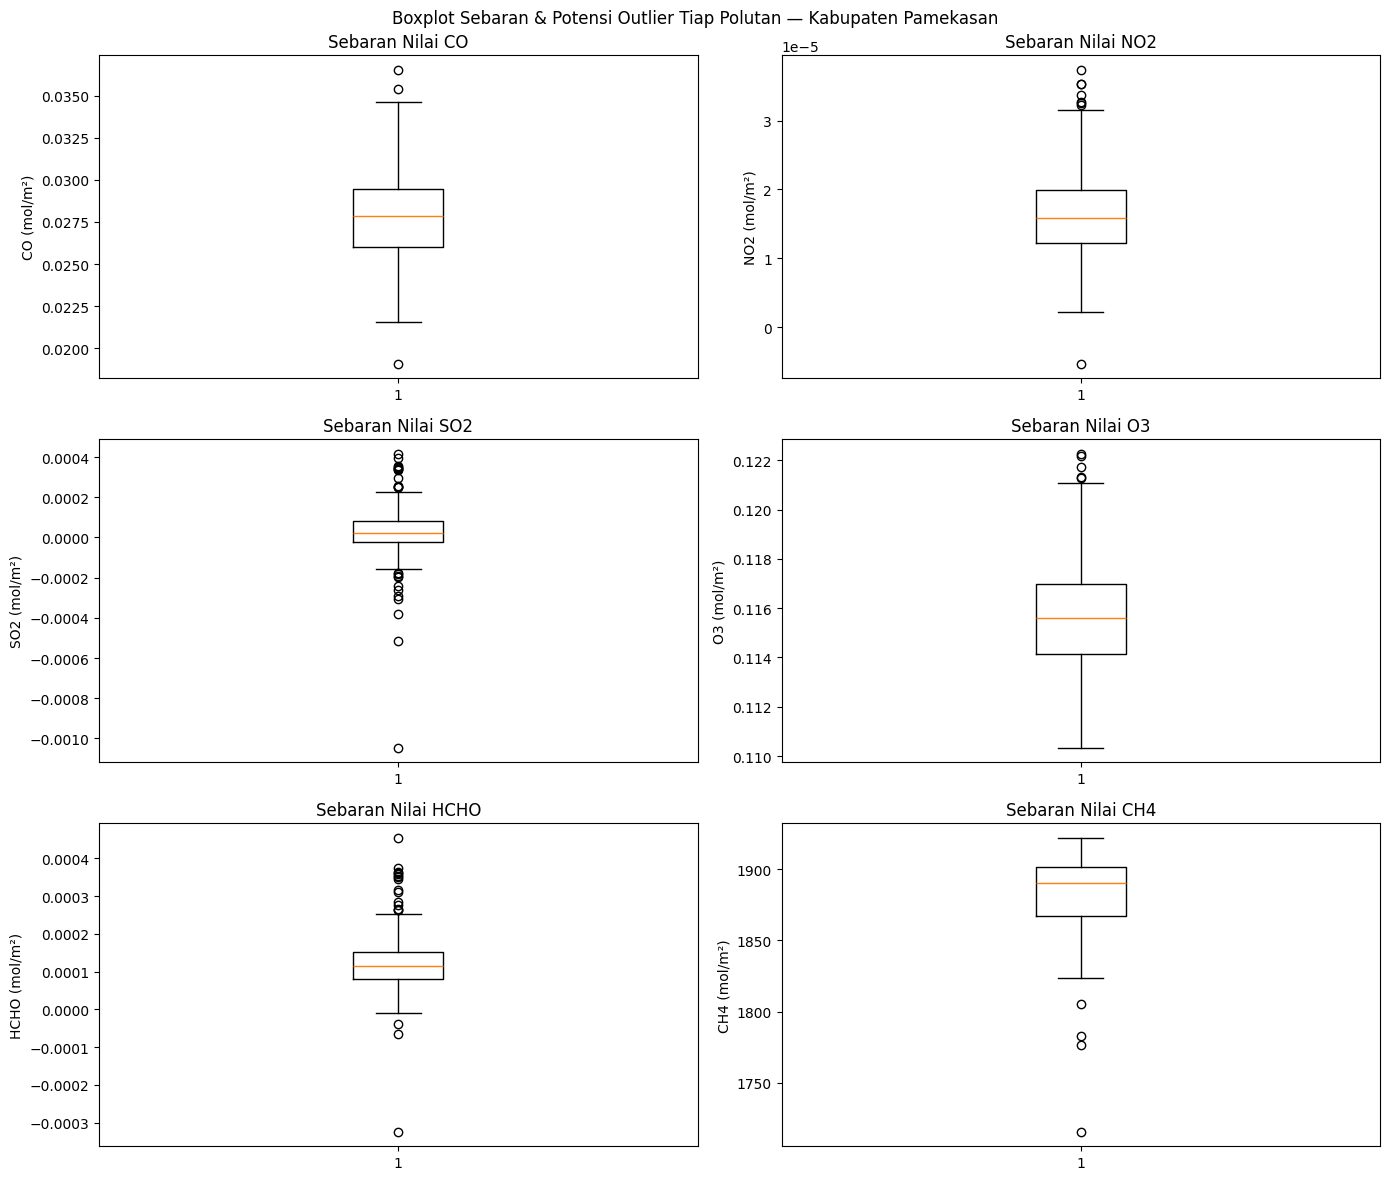

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, gas in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df_polutan_pamekasan[gas].dropna())
    ax.set_title(f"Sebaran Nilai {gas}")
    ax.set_ylabel(f"{gas} (mol/m²)")

fig.suptitle("Boxplot Sebaran & Potensi Outlier Tiap Polutan — Kabupaten Pamekasan")
plt.tight_layout()
plt.show()


> Perlu dicatat bahwa nilai negatif pada data kolom Sentinel-5P adalah hal yang **wajar** akibat *noise* sensor, terutama pada wilayah dengan konsentrasi gas yang rendah &mdash; sehingga tidak semua outlier hasil IQR otomatis berarti kesalahan data. Beberapa titik outlier justru bisa mengindikasikan kejadian nyata, misalnya musim pembakaran lahan pertanian atau lonjakan aktivitas kapal nelayan.

## 5. Visualisasi Time Series

Pada bagian ini dibuat dua jenis grafik: grafik gabungan yang telah dinormalisasi ke rentang 0–1 untuk membandingkan pola seluruh polutan dalam satu sumbu, serta grafik terpisah per polutan dengan skala aslinya agar perubahan masing-masing polutan — termasuk CH4 yang datanya sangat terbatas — tetap dapat teramati dengan jelas.

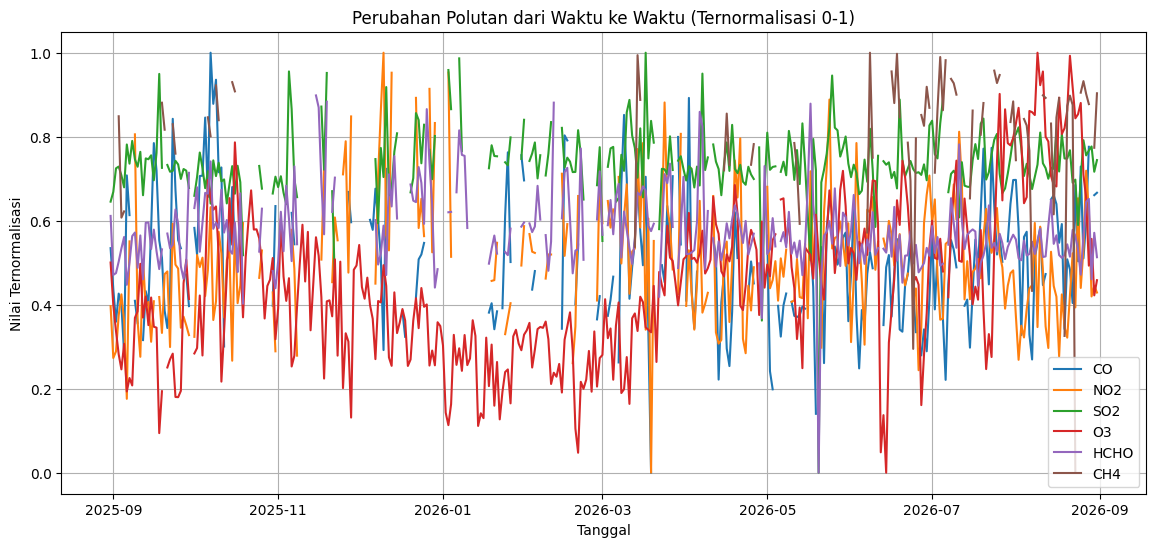

In [14]:
df_ternormalisasi = df_polutan_pamekasan[daftar_polutan].copy()

for gas in daftar_polutan:
    nilai_min = df_ternormalisasi[gas].min()
    nilai_max = df_ternormalisasi[gas].max()
    df_ternormalisasi[gas] = (df_ternormalisasi[gas] - nilai_min) / (nilai_max - nilai_min)

plt.figure(figsize=(14, 6))

for gas in daftar_polutan:
    plt.plot(df_polutan_pamekasan["tanggal"], df_ternormalisasi[gas], label=gas)

plt.title("Perubahan Polutan dari Waktu ke Waktu (Ternormalisasi 0-1)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai Ternormalisasi")
plt.legend()
plt.grid()
plt.show()

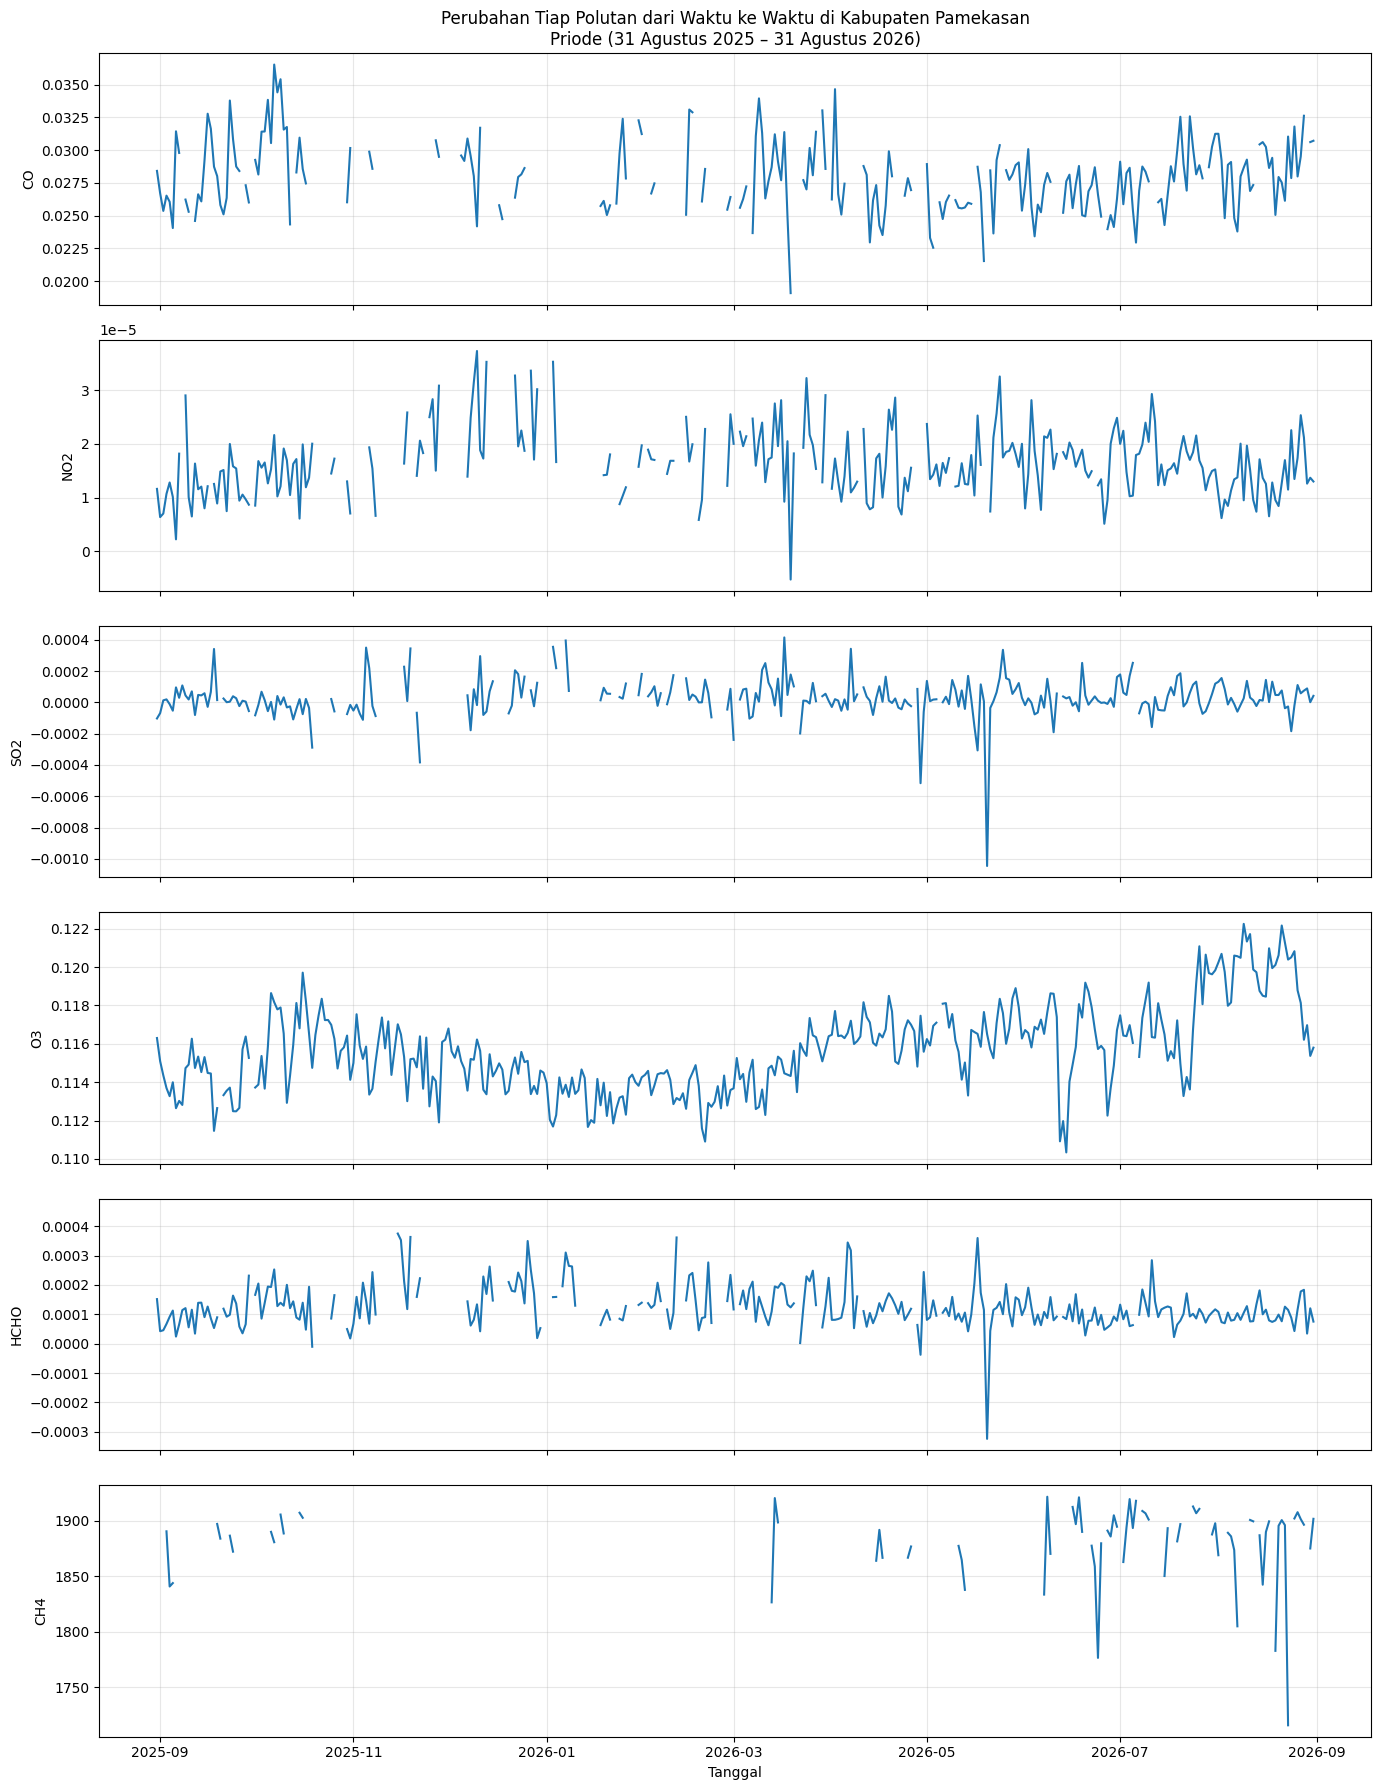

In [17]:
fig, axes = plt.subplots(len(daftar_polutan), 1, figsize=(14, 3 * len(daftar_polutan)), sharex=True)

for ax, gas in zip(axes, daftar_polutan):
    ax.plot(df_polutan_pamekasan["tanggal"], df_polutan_pamekasan[gas], color="tab:blue")
    ax.set_ylabel(gas)
    ax.grid(alpha=0.3)

axes[0].set_title("Perubahan Tiap Polutan dari Waktu ke Waktu di Kabupaten Pamekasan\nPriode (31 Agustus 2025 – 31 Agustus 2026)")
axes[-1].set_xlabel("Tanggal")

plt.tight_layout()
plt.show()

## Kesimpulan

Melalui tugas ini, data konsentrasi enam polutan udara (CO, NO2, SO2, O3, HCHO, dan CH4) di Kabupaten Pamekasan berhasil diperoleh dari satelit Sentinel-5P menggunakan layanan openEO pada Copernicus Data Space Ecosystem, dengan wilayah analisa dibatasi melalui berkas GeoJSON yang digambar di geojson.io. Karena keterbatasan satu *band* per permintaan pada API, pengambilan data dilakukan bergiliran untuk tiap gas dan hasil akhirnya digabungkan menjadi satu berkas CSV. Tahap *data understanding* yang dilakukan mencakup pemeriksaan struktur dan isi data, deskripsi tiap fitur, identifikasi missing value (umumnya akibat tutupan awan), serta deteksi data anomali/outlier dengan metode IQR. Grafik *time series* yang dihasilkan menunjukkan pola fluktuasi tiap polutan sepanjang satu tahun pengamatan, yang diduga berkaitan dengan aktivitas pertanian, peternakan sapi, produksi garam, perikanan, serta lalu lintas kendaraan di wilayah Pamekasan. Temuan tahap ini menjadi dasar bagi tahap pembersihan data dan pemodelan lanjutan pada pertemuan berikutnya.

# Penyimpanan Data ke PostgreSQL (Aiven) dan Penarikannya ke KNIME

## 1. Penyimpanan Data ke Basis Data (PostgreSQL — Aiven)

Selain disimpan dalam bentuk berkas CSV, data polutan yang telah diperoleh pada tahap sebelumnya juga dipindahkan ke basis data PostgreSQL yang di-hosting pada layanan Aiven. Langkah ini dilakukan agar data dapat diakses kembali secara terpusat, misalnya melalui KNIME Analytics Platform atau aplikasi lain, tanpa bergantung pada ketersediaan berkas lokal.

Seluruh kredensial koneksi (host, port, username, dan password) tidak dituliskan secara eksplisit di dalam kode, melainkan diambil melalui fitur Colab Secrets. Pendekatan ini diterapkan untuk mencegah kredensial tersebut ikut terekspos apabila notebook ini dibagikan atau diunggah ke repositori publik.

In [13]:
# membaca ulang CSV pollutant_data_manado.csv, lalu mengunggahnya ke basis data PostgreSQL (Aiven)
import pandas as pd
from sqlalchemy import create_engine
from google.colab import userdata

df_baru = pd.read_csv("data_polutan_pamekasan.csv")

AIVEN_USER     = userdata.get("AIVEN_USER")
AIVEN_PASSWORD = userdata.get("AIVEN_PASSWORD")
AIVEN_HOST     = userdata.get("AIVEN_HOST")
AIVEN_PORT     = userdata.get("AIVEN_PORT")
AIVEN_DB       = userdata.get("AIVEN_DB")

db_url = f"postgresql+psycopg2://{AIVEN_USER}:{AIVEN_PASSWORD}@{AIVEN_HOST}:{AIVEN_PORT}/{AIVEN_DB}?sslmode=require"
engine = create_engine(db_url)

df_baru.to_sql("Polutan_pamekasan", engine, if_exists="replace", index=False)

print(f"Berhasil! {len(df_baru)} baris terupload ke Aiven.")
print(pd.read_sql('SELECT * FROM "Polutan_pamekasan" LIMIT 5', engine))

Berhasil! 366 baris terupload ke Aiven.
      tanggal        CO       NO2       SO2        O3      HCHO          CH4
0  2025-08-31  0.028413  0.000012 -0.000103  0.116304  0.000152          NaN
1  2025-09-01  0.026705  0.000006 -0.000069  0.115098  0.000043          NaN
2  2025-09-02  0.025357  0.000007  0.000013  0.114357  0.000046          NaN
3  2025-09-03  0.026524  0.000011  0.000019  0.113698  0.000067  1890.583083
4  2025-09-04  0.026057  0.000013 -0.000011  0.113273  0.000092  1840.894531


Penjelasan kode di atas adalah sebagai berikut.

- Fungsi `pd.read_csv("data_polutan_pamekasan.csv")` digunakan untuk membaca kembali berkas CSV yang telah dihasilkan pada tahap *Data Understanding* sebelumnya.
- Kelima variabel kredensial (`AIVEN_USER`, `AIVEN_PASSWORD`, `AIVEN_HOST`, `AIVEN_PORT`, `AIVEN_DB`) diperoleh melalui `userdata.get()` dari Colab Secrets, bukan dituliskan secara langsung pada kode.
- Fungsi `create_engine()` digunakan untuk membentuk koneksi ke basis data PostgreSQL Aiven melalui driver `psycopg2`, dengan parameter `sslmode=require` karena Aiven mewajibkan koneksi yang terenkripsi.
- Fungsi `df_baru.to_sql("Polutan_pamekasan", engine, if_exists="replace", index=False)` mengirimkan seluruh isi dataframe ke tabel `Polutan_pamekasan` pada basis data tersebut. Parameter `if_exists="replace"` berarti tabel yang sudah ada sebelumnya akan digantikan dengan data terbaru.
- Dua baris `print()` pada bagian akhir kode berfungsi sebagai verifikasi, yaitu menampilkan jumlah baris yang berhasil diunggah beserta lima baris data teratas hasil kueri dari tabel tersebut.

## 2. Menarik Data dari PostgreSQL (Aiven) ke KNIME

Setelah data polutan tersimpan pada basis data Aiven, tahap selanjutnya adalah menarik data tersebut ke KNIME Analytics Platform untuk keperluan eksplorasi lebih lanjut. Alur kerja yang digunakan tersusun atas empat node yang saling terhubung secara berurutan, yaitu **PostgreSQL Connector**, **DB Table Selector**, **DB Reader**, dan **Statistics**.
   > ![image](https://hackmd.io/_uploads/r10KtLKOfl.png)

### 2.1 PostgreSQL Connector

Berfungsi membuka koneksi ke server Aiven. Konfigurasi yang diisikan meliputi hostname sesuai `AIVEN_HOST`, port sesuai `AIVEN_PORT`, nama basis data `defaultdb`, serta username dan password sesuai kredensial Aiven, dengan SSL Mode diatur ke `require` karena Aiven mewajibkan koneksi terenkripsi. Dua port opsional pada bagian atas node dapat digunakan untuk menyuntikkan kredensial melalui flow variable; apabila tidak dihubungkan, username dan password dapat diisikan langsung pada tab konfigurasi node.

   > ![image](https://hackmd.io/_uploads/SJlKc8tOfg.png)

### 2.2 DB Table Selector

Dihubungkan ke output PostgreSQL Connector, kemudian digunakan untuk memilih tabel `Polutan_pamekasan` yang sebelumnya telah dibuat melalui fungsi `to_sql()`.

  > ![image](https://hackmd.io/_uploads/HJ8JiIFOzl.png)

### 2.3 DB Reader

Mengeksekusi kueri dari DB Table Selector dan mengonversi hasilnya menjadi tabel KNIME biasa, sehingga siap diproses oleh node analisis berikutnya.

  > ![image](https://hackmd.io/_uploads/H15xvaFuze.png)

### 2.4 Statistics

Dihubungkan langsung ke output DB Reader dan digunakan untuk menghitung ringkasan statistik (mean, median, standar deviasi, variance, min, max, kuartil, skewness, kurtosis, dan sebagainya) untuk setiap kolom polutan. Node ini memiliki tiga output port, yaitu Statistics Table, Nominal Histogram Table, dan Occurrences Table.

   > ![image](https://hackmd.io/_uploads/HkXYFTtOzl.png)

   > ![image](https://hackmd.io/_uploads/SkVRYpK_fg.png)

  > ![image](https://hackmd.io/_uploads/B1YRK6Ydfg.png)


Beberapa ukuran statistik yang dihasilkan oleh node ini meliputi:

- **Min**, yaitu nilai terkecil pada kolom.
- **Max**, yaitu nilai terbesar pada kolom.
- **Mean**, yaitu nilai rata-rata data.
- **Variance**, yaitu ukuran penyebaran data terhadap nilai rata-ratanya.
- **Std. Deviation**, yaitu akar dari variance yang lebih mudah diinterpretasikan karena memiliki satuan yang sama dengan data asli.
- **Skewness**, yaitu ukuran kemencengan (asimetri) distribusi data.
- **Kurtosis**, yaitu ukuran keruncingan distribusi data dibandingkan dengan distribusi normal.
- **Overall Sum**, yaitu jumlah seluruh nilai numerik pada kolom.
- **No. Missings**, yaitu jumlah baris yang tidak memiliki nilai pada kolom tersebut.
- **No. NaNs**, yaitu jumlah nilai yang secara eksplisit bertipe *Not a Number*.
- **No. +oos** dan **No. -oos**, yaitu jumlah nilai positif dan negatif yang berada di luar batas (*out of spec*) yang ditetapkan.
- **Median**, yaitu nilai tengah data setelah diurutkan.
- **Row Count**, yaitu jumlah seluruh baris tabel, termasuk baris yang bernilai *missing*. Perlu digarisbawahi bahwa Row Count berbeda dengan jumlah data yang benar-benar digunakan dalam perhitungan Mean, Variance, dan statistik numerik lainnya, karena nilai *missing* tidak diikutsertakan dalam perhitungan tersebut.

## 3. Ilustrasi Perhitungan Statistik

Sebagai ilustrasi cara kerja node Statistics, diambil data kolom **CO** pada lima baris pertama data Pamekasan:

| Hari | Tanggal | CO |
|---|---|---|
| 1 | 2025-08-31 | 0,028413 |
| 2 | 2025-09-01 | 0,026705 |
| 3 | 2025-09-02 | 0,025357 |
| 4 | 2025-09-03 | 0,026524 |
| 5 | 2025-09-04 | 0,026057 |

Berbeda dari contoh milik teman (yang kebetulan memiliki satu baris kosong), pada lima baris pertama data Pamekasan ini seluruh nilai CO tercatat lengkap, sehingga banyaknya data yang dipakai dalam perhitungan berikut adalah $n = 5$.

### 3.1 Min

Min adalah nilai paling kecil di antara seluruh data yang tersedia.

$$\text{Min} = \min(x_1, x_2, \dots, x_n)$$

$$\text{Min} = \min(0{,}028413;\ 0{,}026705;\ 0{,}025357;\ 0{,}026524;\ 0{,}026057) = 0{,}025357$$

Sehingga Min CO = 0,025357.

### 3.2 Max

Kebalikan dari Min, Max adalah nilai paling besar di antara data yang ada.

$$\text{Max} = \max(x_1, x_2, \dots, x_n)$$

$$\text{Max} = \max(0{,}028413;\ 0{,}026705;\ 0{,}025357;\ 0{,}026524;\ 0{,}026057) = 0{,}028413$$

Sehingga Max CO = 0,028413.

### 3.3 Mean

Mean menggambarkan nilai tengah keseluruhan data, diperoleh dari total nilai dibagi banyaknya data.

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

$$\bar{x} = \frac{0{,}028413 + 0{,}026705 + 0{,}025357 + 0{,}026524 + 0{,}026057}{5} = \frac{0{,}133056}{5} = 0{,}0266112$$

Sehingga Mean CO = 0,0266112.

### 3.4 Variance

Variance menunjukkan besarnya penyebaran data terhadap nilai rata-ratanya. Pada contoh ini digunakan rumus *sample variance*:

$$s^2 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}$$

Dengan $\bar{x} = 0{,}0266112$, selisih tiap nilai terhadap mean beserta kuadratnya adalah sebagai berikut:

| $x_i$ | $x_i - \bar{x}$ | $(x_i-\bar{x})^2$ |
|---|---|---|
| 0,028413 | 0,0018018 | 0,00000325 |
| 0,026705 | 0,0000938 | 0,00000001 |
| 0,025357 | -0,0012542 | 0,00000157 |
| 0,026524 | -0,0000872 | 0,00000001 |
| 0,026057 | -0,0005542 | 0,00000031 |

Jumlah seluruh kuadrat selisih tersebut $\approx 0{,}0000051430$, sehingga:

$$s^2 = \frac{0{,}0000051430}{5-1} \approx 0{,}0000012858$$

Diperoleh Variance CO ≈ 0,0000012858.

### 3.5 Std. Deviation

Standar deviasi merupakan akar dari variance, dan lebih mudah diinterpretasikan karena satuannya sama dengan data aslinya.

$$s = \sqrt{s^2} = \sqrt{0{,}0000012858} \approx 0{,}0011339$$

Diperoleh Std. Deviation CO ≈ 0,0011339.

### 3.6 Skewness

Skewness mengukur tingkat kemencengan (asimetri) distribusi data, menggunakan rumus *corrected sample skewness*:

$$G_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$

Dengan $n = 5$, $\bar{x} = 0{,}0266112$, dan $s \approx 0{,}0011339$, diperoleh:

$$G_1 \approx 1{,}0593$$

Nilai Skewness CO ≈ 1,0593 ini bertanda positif, menandakan distribusi data pada lima baris ini sedikit condong ke arah kanan (didominasi nilai rendah dengan satu nilai yang relatif tinggi di baris pertama).

### 3.7 Kurtosis

Kurtosis menggambarkan tingkat keruncingan distribusi dibandingkan distribusi normal, dihitung dengan rumus *corrected sample excess kurtosis*:

$$G_2 = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}$$

Dengan $n = 5$, hasil perhitungannya:

$$G_2 \approx 1{,}9116$$

Nilai Kurtosis CO ≈ 1,9116 yang positif ini mengindikasikan bahwa distribusi data pada lima baris ini lebih runcing (lebih terpusat, dengan sedikit nilai ekstrem) dibandingkan distribusi normal.

### 3.8 Overall Sum

Overall Sum adalah total penjumlahan seluruh nilai numerik yang tersedia pada kolom tersebut.

$$\text{Sum} = \sum_{i=1}^{n} x_i$$

$$\text{Sum} = 0{,}028413 + 0{,}026705 + 0{,}025357 + 0{,}026524 + 0{,}026057 = 0{,}133056$$

Sehingga Overall Sum CO = 0,133056.

### 3.9 No. Missings

Fitur ini mencatat jumlah baris yang tidak memiliki nilai (kosong) pada kolom tersebut. Karena pada lima baris pertama ini seluruh data CO terisi lengkap:

$$\text{No. Missings} = 0$$

### 3.10 No. NaNs

Berbeda dari missing value, No. NaNs khusus menghitung nilai yang secara eksplisit bertipe *Not a Number*. Pada contoh ini juga tidak ditemukan nilai semacam itu:

$$\text{No. NaNs} = 0$$

### 3.11 No. +oos

Fitur ini menunjukkan banyaknya nilai positif yang berada di luar batas (*out of spec*) yang ditetapkan. Tidak ada data pada contoh ini yang termasuk kategori tersebut:

$$\text{No. } {+oos} = 0$$

### 3.12 No. -oos

Sebaliknya, fitur ini menghitung nilai negatif yang berada di luar batas yang ditetapkan. Pada contoh ini juga tidak ditemukan data semacam itu:

$$\text{No. } {-oos} = 0$$

### 3.13 Median

Median merupakan nilai yang berada tepat di tengah setelah data diurutkan. Data yang telah diurutkan:

$$0{,}025357;\ 0{,}026057;\ 0{,}026524;\ 0{,}026705;\ 0{,}028413$$

Karena jumlah data ganjil ($n = 5$), median diambil langsung dari nilai tengah (data ke-3):

$$\text{Median} = x_{(3)} = 0{,}026524$$

Sehingga Median CO = 0,026524.

### 3.14 Row Count

Row Count menghitung seluruh baris pada tabel, termasuk yang bernilai missing. Pada contoh ini terdapat 5 baris:

$$\text{Row Count} = 5$$

Perlu digarisbawahi bahwa Row Count tidak selalu sama dengan jumlah data yang dipakai dalam perhitungan Mean, Variance, dan statistik numerik lainnya — pada contoh ini kebetulan sama karena tidak ada nilai yang kosong, namun akan berbeda bila salah satu barisnya missing (seperti pada kolom CH4, yang sebagian datanya belum tersedia pada rentang lima baris ini).



## Kesimpulan

Data polutan yang telah tersimpan sebagai CSV diunggah ke basis data PostgreSQL (Aiven), dengan kredensial disimpan lewat Colab Secrets agar tidak ikut terekspos. Data tersebut kemudian ditarik ke KNIME melalui alur empat node — PostgreSQL Connector, DB Table Selector, DB Reader, dan Statistics — untuk menghasilkan ringkasan statistik tiap polutan secara otomatis. Hasilnya sejalan dengan perhitungan manual pada bagian sebelumnya, sehingga proses penyimpanan dan penarikan data antara Aiven dan KNIME dapat dipastikan berjalan dengan benar.